In [1]:
# --- Cell 1: imports ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs import CLASSES
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.evaluations.metrics import evaluate_loader, evaluate_source_val
from task2.evaluations.domain_separability import domain_separability, collect_features
from task2.evaluations.class_analysis import (per_class_table, class_deltas,
                                              dominant_confusions, predicted_distribution)

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../../datasets/PACS'
METHODS = ['source_only', 'dan', 'dann', 'cdan']
CKPT = {m: f'../../datasets/cache/task2_{m}.pt' for m in METHODS}

In [2]:
# --- Cell 2: loaders ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits, batch_per_source=8, target_batch=24,
                        eval_batch=64, num_workers=0, seed=6304)
print('target eval images:', len(loaders['target_eval'].dataset))
print('source val images :', sum(len(l.dataset) for l in loaders['source_val'].values()))

target eval images: 3929
source val images : 1213


In [3]:
# --- Cell 3: evaluate all four on source val AND target ---
results = {}
for m in METHODS:
    ck = torch.load(CKPT[m], map_location=device, weights_only=False)
    model = PACSModel(num_classes=7).to(device)
    model.load_state_dict(ck['model'])

    sv = evaluate_source_val(model, loaders['source_val'], device)
    tg = evaluate_loader(model, loaders['target_eval'], device, collect_features=True)

    results[m] = {'best_epoch': ck['best_epoch'], 'source_val': sv,
                  'target': {'accuracy': tg['accuracy'], 'macro_f1': tg['macro_f1'],
                             'n': tg['n']},
                  '_preds': tg['preds'], '_labels': tg['labels'], '_feats': tg['features'],
                  '_model': model}
    print(f"{m:12s} src_f1={sv['mean_macro_f1']:.4f}  "
          f"tgt_acc={tg['accuracy']:.4f}  tgt_f1={tg['macro_f1']:.4f}")

source_only  src_f1=0.9385  tgt_acc=0.6373  tgt_f1=0.6557
dan          src_f1=0.9412  tgt_acc=0.6281  tgt_f1=0.5810
dann         src_f1=0.9382  tgt_acc=0.0812  tgt_f1=0.0946
cdan         src_f1=0.9176  tgt_acc=0.6839  tgt_f1=0.6385


In [4]:
# --- Cell 4: domain separability  ---
for m in METHODS:
    src_f = np.concatenate([collect_features(results[m]['_model'], ld, device)[0]
                            for ld in loaders['source_val'].values()])
    sep = domain_separability(src_f, results[m]['_feats'], seed=6304)
    results[m]['separability'] = sep
    print(f"{m:12s} separability={sep['separability']:.4f} "
          f"(n={sep['n_per_domain']} per domain, chance=0.50)")

source_only  separability=1.0000 (n=1213 per domain, chance=0.50)
dan          separability=0.8626 (n=1213 per domain, chance=0.50)
dann         separability=1.0000 (n=1213 per domain, chance=0.50)
cdan         separability=0.9959 (n=1213 per domain, chance=0.50)


In [5]:
# --- Cell 5:comparison table ---
base_acc = results['source_only']['target']['accuracy']
rows = []
for m in METHODS:
    r = results[m]
    pd_ = r['source_val']['per_domain']
    rows.append({
        'method': m, 'best_epoch': r['best_epoch'],
        **{f'src_{d}_f1': round(pd_[d]['macro_f1'], 4) for d in pd_},
        'src_mean_acc': round(r['source_val']['mean_accuracy'], 4),
        'src_mean_f1': round(r['source_val']['mean_macro_f1'], 4),
        'tgt_acc': round(r['target']['accuracy'], 4),
        'tgt_f1': round(r['target']['macro_f1'], 4),
        'tgt_acc_delta': round(r['target']['accuracy'] - base_acc, 4),
        'separability': round(r['separability']['separability'], 4),
    })
import pandas as pd
df = pd.DataFrame(rows)
print(df.to_string(index=False))

     method  best_epoch  src_photo_f1  src_art_painting_f1  src_cartoon_f1  src_mean_acc  src_mean_f1  tgt_acc  tgt_f1  tgt_acc_delta  separability
source_only           8        0.9715               0.8947          0.9492        0.9395       0.9385   0.6373  0.6557         0.0000        1.0000
        dan           7        0.9556               0.9076          0.9605        0.9412       0.9412   0.6281  0.5810        -0.0092        0.8626
       dann           7        0.9618               0.9142          0.9385        0.9393       0.9382   0.0812  0.0946        -0.5561        1.0000
       cdan           2        0.9619               0.8672          0.9237        0.9181       0.9176   0.6839  0.6385         0.0466        0.9959


In [6]:
# --- Cell 6: per-class target accuracy, deltas, confusions ---
tables = {m: per_class_table(results[m]['_preds'], results[m]['_labels'], CLASSES)
          for m in METHODS}
base = tables['source_only']

print('support per class:', {c: base[c]['support'] for c in CLASSES}, '\n')
for m in METHODS:
    print(f"--- {m} per-class accuracy ---")
    print({c: round(tables[m][c]['accuracy'], 3) for c in CLASSES})
    if m != 'source_only':
        d = class_deltas(base, tables[m], CLASSES)
        ranked = sorted(d.items(), key=lambda kv: kv[1]['delta'])
        print(f"  worst: {ranked[0][0]} {ranked[0][1]['delta']:+.3f} "
              f"(support {ranked[0][1]['support']})")
        print(f"  best : {ranked[-1][0]} {ranked[-1][1]['delta']:+.3f} "
              f"(support {ranked[-1][1]['support']})")
    print('  predicted label counts:',
          predicted_distribution(results[m]['_preds'], CLASSES))
    print()

support per class: {'dog': 772, 'elephant': 740, 'giraffe': 753, 'guitar': 608, 'horse': 816, 'house': 80, 'person': 160} 

--- source_only per-class accuracy ---
{'dog': 0.455, 'elephant': 0.969, 'giraffe': 0.587, 'guitar': 0.837, 'horse': 0.451, 'house': 0.875, 'person': 0.294}
  predicted label counts: {'dog': 634, 'elephant': 1602, 'giraffe': 536, 'guitar': 518, 'horse': 509, 'house': 77, 'person': 53}

--- dan per-class accuracy ---
{'dog': 0.316, 'elephant': 0.784, 'giraffe': 0.587, 'guitar': 0.762, 'horse': 0.68, 'house': 1.0, 'person': 0.65}
  worst: elephant -0.185 (support 740)
  best : person +0.356 (support 160)
  predicted label counts: {'dog': 302, 'elephant': 672, 'giraffe': 566, 'guitar': 464, 'horse': 655, 'house': 489, 'person': 781}

--- dann per-class accuracy ---
{'dog': 0.032, 'elephant': 0.0, 'giraffe': 0.125, 'guitar': 0.186, 'horse': 0.007, 'house': 1.0, 'person': 0.006}
  worst: elephant -0.969 (support 740)
  best : house +0.125 (support 80)
  predicted label

In [7]:
# --- Cell 7: dominant confusions for the classes that moved most ---
for m in METHODS:
    conf = dominant_confusions(results[m]['_preds'], results[m]['_labels'], CLASSES)
    print(f"--- {m} ---")
    for c in CLASSES:
        if conf[c]:
            top = ', '.join(f"{x['predicted']}({x['count']})" for x in conf[c])
            print(f"  true {c:9s} -> {top}")
    print()

--- source_only ---
  true dog       -> elephant(337), horse(53), giraffe(26)
  true elephant  -> dog(21), giraffe(1), horse(1)
  true giraffe   -> elephant(124), dog(90), horse(87)
  true guitar    -> elephant(86), giraffe(8), dog(4)
  true horse     -> elephant(264), dog(137), giraffe(43)
  true house     -> elephant(10)
  true person    -> elephant(64), dog(31), giraffe(16)

--- dan ---
  true dog       -> person(284), house(78), horse(72)
  true elephant  -> house(79), person(71), horse(4)
  true giraffe   -> person(201), house(45), dog(27)
  true guitar    -> house(57), person(52), giraffe(33)
  true horse     -> house(94), person(69), giraffe(44)
  true person    -> house(56)

--- dann ---
  true dog       -> house(746), person(1)
  true elephant  -> house(740)
  true giraffe   -> house(658), dog(1)
  true guitar    -> house(474), giraffe(21)
  true horse     -> house(810)
  true person    -> house(159)

--- cdan ---
  true dog       -> horse(301), person(164), elephant(154)
  tr

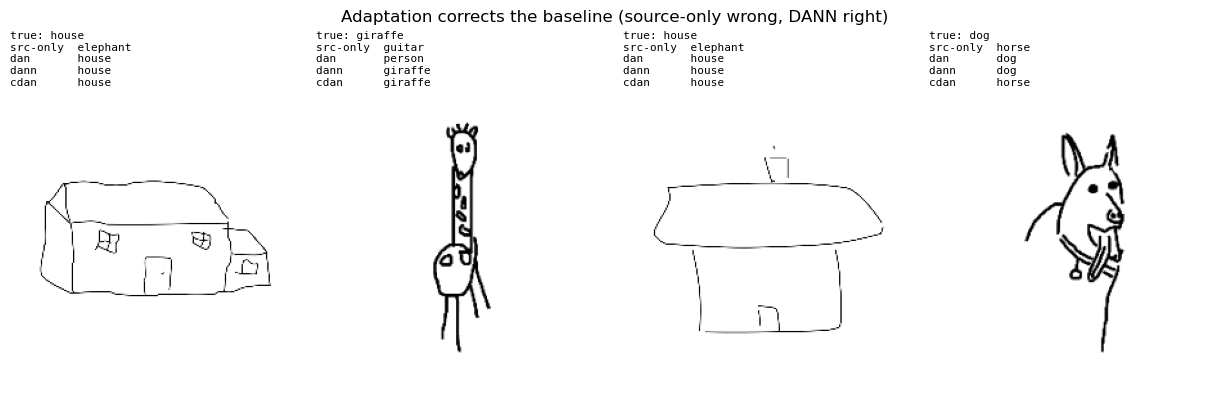

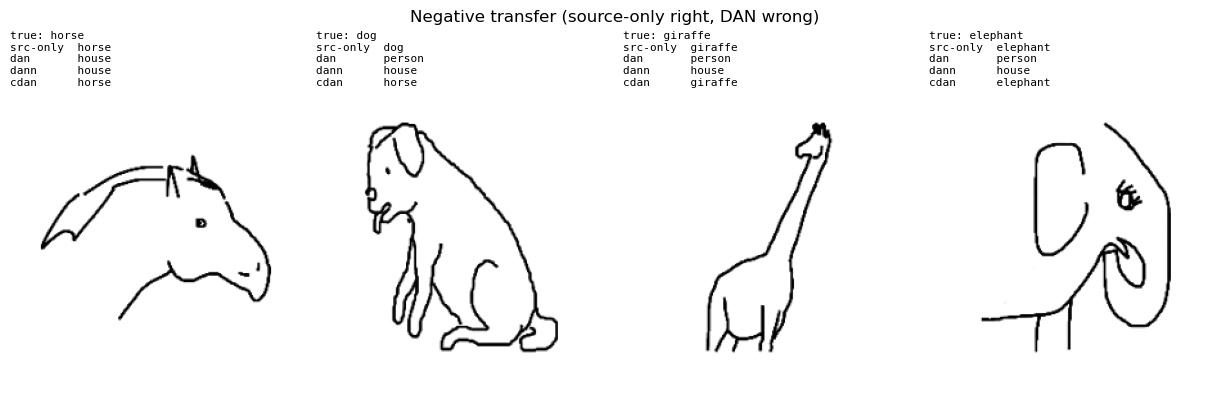

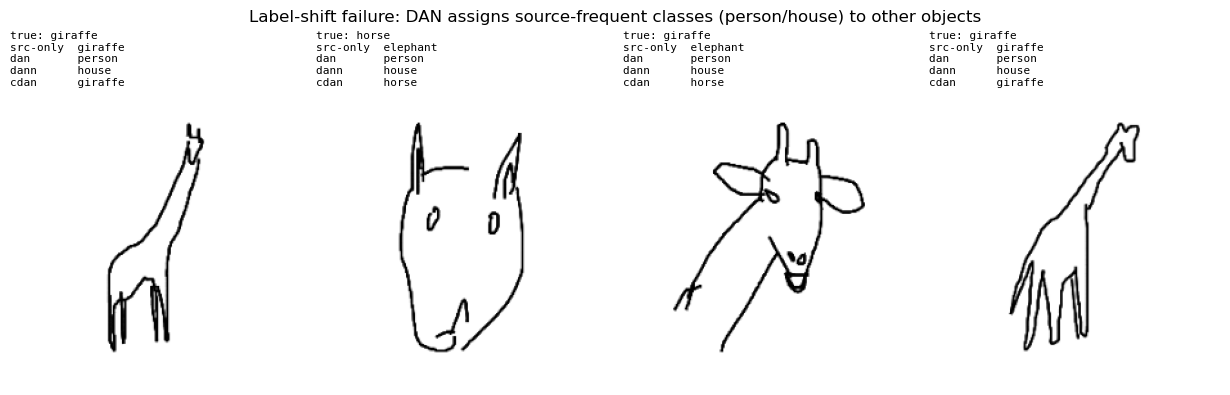

counts -> corrected by DANN: 21, broken by DAN: 659, label-shift misassignments by DAN: 1030


In [8]:
# --- Cell 7b: informative failure cases (the manual's "selected confusions") ---
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

tgt_records = splits['domains']['sketch']['all']          # index order matches preds/labels
P = {m: results[m]['_preds'] for m in METHODS}
y = results['source_only']['_labels']

def show(idx, title, fname, ncols=4):
    """One row of sketches with every method's prediction under each."""
    n = len(idx)
    fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 4.0))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, idx):
        ax.imshow(Image.open(Path(DATA_ROOT) / tgt_records[i]['path']).convert('RGB'),
                  cmap='gray')
        ax.axis('off')
        lines = [f"true: {CLASSES[y[i]]}"] + \
                [f"{m.replace('source_only','src-only'):9s} {CLASSES[P[m][i]]}" for m in METHODS]
        ax.set_title('\n'.join(lines), fontsize=8, loc='left', family='monospace')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../../report/figures/{fname}', dpi=200, bbox_inches='tight')
    plt.show()

rng = np.random.default_rng(6304)      # selection is seeded, not cherry-picked

# (a) ADAPTATION FIXED IT: source-only wrong, the best adaptation method right
fixed = np.flatnonzero((P['source_only'] != y) & (P['dann'] == y))
show(rng.choice(fixed, 4, replace=False), 
     'Adaptation corrects the baseline (source-only wrong, DANN right)',
     'task2_cases_fixed.png')

# (b) ADAPTATION BROKE IT: source-only right, adaptation wrong = negative transfer
broke = np.flatnonzero((P['source_only'] == y) & (P['dan'] != y))
show(rng.choice(broke, 4, replace=False),
     'Negative transfer (source-only right, DAN wrong)',
     'task2_cases_broken.png')

# (c) THE LABEL-SHIFT FAILURE: not a person/house, but predicted as one by DAN
#     -- this is the pre-registered prediction made visible
person_idx = CLASSES.index('person'); house_idx = CLASSES.index('house')
shift = np.flatnonzero((y != person_idx) & (y != house_idx) &
                       np.isin(P['dan'], [person_idx, house_idx]))
show(rng.choice(shift, 4, replace=False),
     'Label-shift failure: DAN assigns source-frequent classes (person/house) to other objects',
     'task2_cases_labelshift.png')

print(f"counts -> corrected by DANN: {len(fixed)}, broken by DAN: {len(broke)}, "
      f"label-shift misassignments by DAN: {len(shift)}")

In [9]:
# --- Cell 8: MMD bias-floor control (planned at Step 2) ---
from task2.methods.dan import mmd_rbf

m = 'dan'
src_f = np.concatenate([collect_features(results[m]['_model'], ld, device)[0]
                        for ld in loaders['source_val'].values()])
rng = np.random.default_rng(6304)
perm = rng.permutation(len(src_f))
half = len(perm) // 2

a = torch.tensor(src_f[perm[:24]]); b = torch.tensor(src_f[perm[half:half + 24]])
floor = mmd_rbf(a, b).item()
st = torch.tensor(results[m]['_feats'][rng.permutation(len(results[m]['_feats']))[:24]])
cross = mmd_rbf(a, st).item()
print(f"MMD source-half vs source-half (floor): {floor:.4f}")
print(f"MMD source vs target on DAN backbone  : {cross:.4f}")

MMD source-half vs source-half (floor): 0.1198
MMD source vs target on DAN backbone  : 0.1529


In [10]:
# --- Cell 8b: is the residual separability carried by feature MAGNITUDE? ---
# Our DANN/CDAN discriminators saw L2-normalised features, so they could not use
# norm as a domain cue. This probe uses raw features and can. Re-running it on
# normalised features isolates how much domain information lives in direction.
def l2n(a):
    return a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)

print(f"{'method':12s} {'raw':>8s} {'normalised':>12s} {'|f| src':>9s} {'|f| tgt':>9s}")
for m in METHODS:
    src_f = np.concatenate([collect_features(results[m]['_model'], ld, device)[0]
                            for ld in loaders['source_val'].values()])
    tgt_f = results[m]['_feats']
    raw = results[m]['separability']['separability']
    nrm = domain_separability(l2n(src_f), l2n(tgt_f), seed=6304)['separability']
    results[m]['separability']['normalised'] = nrm
    print(f"{m:12s} {raw:8.4f} {nrm:12.4f} "
          f"{np.linalg.norm(src_f,axis=1).mean():9.2f} "
          f"{np.linalg.norm(tgt_f,axis=1).mean():9.2f}")

method            raw   normalised   |f| src   |f| tgt
source_only    1.0000       0.9821     69.08     39.13
dan            0.8626       0.6992     15.87     15.92
dann           1.0000       0.9931     67.60     58.33
cdan           0.9959       0.9698     70.08     68.26


In [11]:
# --- Cell 9: save everything ---
out = {'step': 'final_eval', 'seed': 6304, 'classes': list(CLASSES),
       'table': rows,
       'per_class': {m: tables[m] for m in METHODS},
       'deltas': {m: class_deltas(base, tables[m], CLASSES)
                  for m in METHODS if m != 'source_only'},
       'confusions': {m: dominant_confusions(results[m]['_preds'],
                                             results[m]['_labels'], CLASSES)
                      for m in METHODS},
       'predicted_distribution': {m: predicted_distribution(results[m]['_preds'], CLASSES)
                                  for m in METHODS},
       'separability': {m: results[m]['separability'] for m in METHODS},
       'mmd_control': {'source_half_vs_source_half': floor,
                       'source_vs_target_dan': cross}}
save_results(out, '../results/final_eval.json')
print('saved')

saved
